In [ ]:
from sklearn.model_selection import train_test_split

original_rows = len(df)
print(f"Original DataFrame has {original_rows} rows.")

desired_sample_size = 30000
sampling_fraction = desired_sample_size / original_rows
print(f"Desired sample size: {desired_sample_size}")
print(f"Calculated sampling fraction: {sampling_fraction:.4f}")


_, df_sampled = train_test_split(df, test_size=sampling_fraction, stratify=df['Class'], random_state=42)

print(f"\nShape of df_sampled: {df_sampled.shape}")

print("\nClass distribution in df_sampled (value counts):")
print(df_sampled['Class'].value_counts())
print("\nClass distribution in df_sampled (percentage):")
print(df_sampled['Class'].value_counts(normalize=True) * 100)

Original DataFrame has 284807 rows.
Desired sample size: 30000
Calculated sampling fraction: 0.1053

Shape of df_sampled: (30000, 31)

Class distribution in df_sampled (value counts):
Class
0    29948
1       52
Name: count, dtype: int64

Class distribution in df_sampled (percentage):
Class
0    99.826667
1     0.173333
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

print("Missing values per column in df_sampled:")
print(df_sampled.isnull().sum())

print("\nData types in df_sampled:")
print(df_sampled.dtypes)

print("\nClass distribution in df_sampled (value counts):")
print(df_sampled['Class'].value_counts())
print("\nClass distribution in df_sampled (percentage):")
print(df_sampled['Class'].value_counts(normalize=True) * 100)

X_sampled = df_sampled.drop('Class', axis=1)
y_sampled = df_sampled['Class']

print(f"\nShape of features (X_sampled): {X_sampled.shape}")
print(f"Shape of target (y_sampled): {y_sampled.shape}")

X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled = train_test_split(
    X_sampled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
)

print(f"\nShape of X_train_sampled: {X_train_sampled.shape}")
print(f"Shape of X_test_sampled: {X_test_sampled.shape}")
print(f"Shape of y_train_sampled: {y_train_sampled.shape}")
print(f"Shape of y_test_sampled: {y_test_sampled.shape}")

print("\nClass distribution in y_train_sampled (percentage):")
print(y_train_sampled.value_counts(normalize=True) * 100)
print("\nClass distribution in y_test_sampled (percentage):")
print(y_test_sampled.value_counts(normalize=True) * 100)

Missing values per column in df_sampled:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data types in df_sampled:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class  

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

neg_count_sampled = y_train_sampled.value_counts()[0] 
pos_count_sampled = y_train_sampled.value_counts()[1]
scale_pos_weight_sampled = neg_count_sampled / pos_count_sampled
print(f"Calculated scale_pos_weight for sampled data: {scale_pos_weight_sampled:.2f}")

xgb_model_sampled = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_sampled,
    random_state=42
)

print("\nTraining XGBoost model on sampled data...")
xgb_model_sampled.fit(X_train_sampled, y_train_sampled)
print("XGBoost model training on sampled data complete.")

y_pred_sampled = xgb_model_sampled.predict(X_test_sampled)

print("\nClassification Report on Sampled Test Set:")
print(classification_report(y_test_sampled, y_pred_sampled))

Calculated scale_pos_weight for sampled data: 570.43

Training XGBoost model on sampled data...
XGBoost model training on sampled data complete.

Classification Report on Sampled Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5990
           1       0.89      0.80      0.84        10

    accuracy                           1.00      6000
   macro avg       0.94      0.90      0.92      6000
weighted avg       1.00      1.00      1.00      6000



In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_model_sampled = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_sampled,
    random_state=42
)

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model_sampled,
    param_grid=param_grid,
    scoring='f1',
    cv=kf,
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearchCV on sampled data...")
grid_search.fit(X_train_sampled, y_train_sampled)
print("GridSearchCV on sampled data complete.")

print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest F1-score achieved:")
print(grid_search.best_score_)

Starting GridSearchCV on sampled data...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
GridSearchCV on sampled data complete.

Best parameters found:
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}

Best F1-score achieved:
0.8183908045977012


Best XGBoost estimator retrieved.

Classification Report for Tuned Model on Sampled Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5990
           1       0.89      0.80      0.84        10

    accuracy                           1.00      6000
   macro avg       0.94      0.90      0.92      6000
weighted avg       1.00      1.00      1.00      6000



<Figure size 600x500 with 0 Axes>

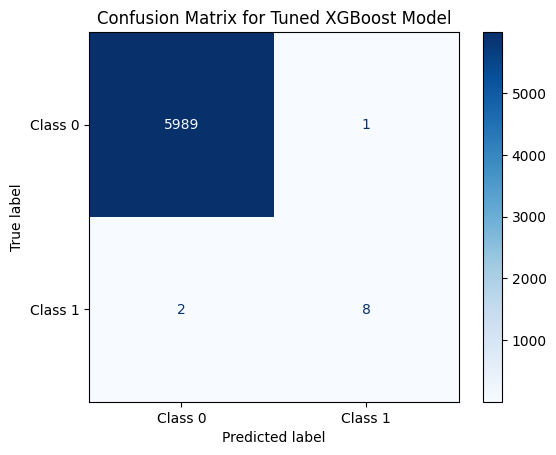

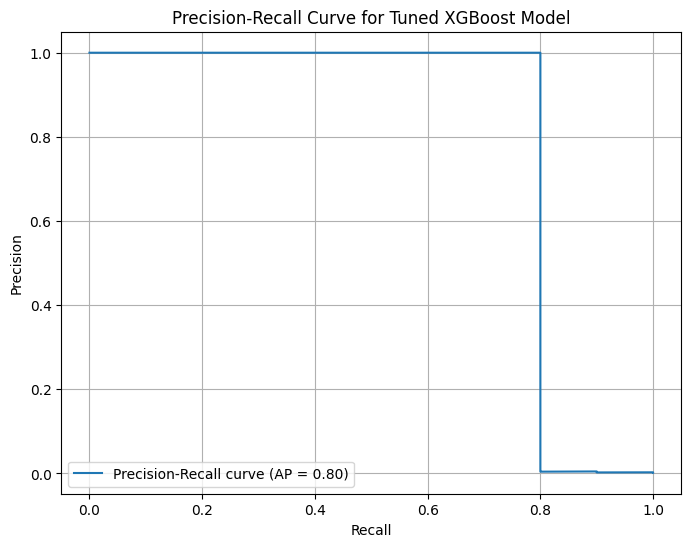

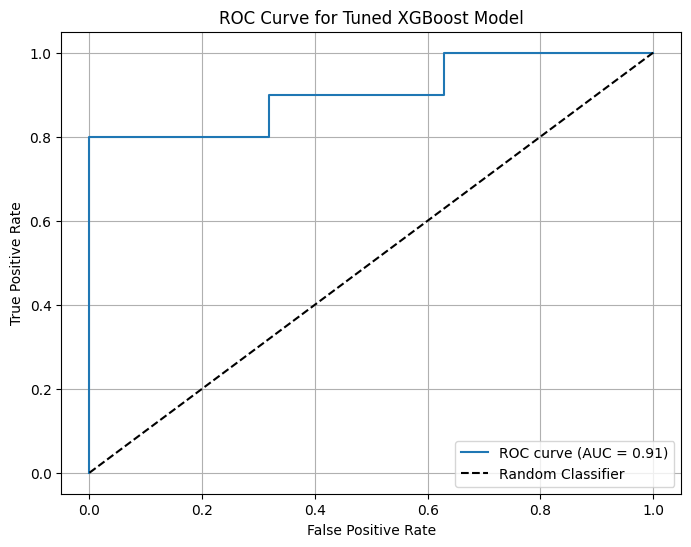

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, roc_auc_score, average_precision_score

best_xgb_model = grid_search.best_estimator_
print("Best XGBoost estimator retrieved.")

y_pred_tuned = best_xgb_model.predict(X_test_sampled)
y_pred_proba_tuned = best_xgb_model.predict_proba(X_test_sampled)[:, 1] 

print("\nClassification Report for Tuned Model on Sampled Test Set:")
print(classification_report(y_test_sampled, y_pred_tuned))

cm = confusion_matrix(y_test_sampled, y_pred_tuned)
plt.figure(figsize=(6, 5))
cmd = ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1'])
cmd.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Tuned XGBoost Model')
plt.show()

precision, recall, _ = precision_recall_curve(y_test_sampled, y_pred_proba_tuned)
ap_score = average_precision_score(y_test_sampled, y_pred_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tuned XGBoost Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

fpr, tpr, _ = roc_curve(y_test_sampled, y_pred_proba_tuned)
roc_auc = roc_auc_score(y_test_sampled, y_pred_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()